# 09 · Phase 10 — The configuration MDP and its dynamic-programming solution (24AIM304 Unit 2)

**Finite MDP** (horizon H = 5, γ = 1):

| element | definition |
|---|---|
| state s_t | (context k, components chosen so far a_0 … a_{t−1}) — 396 states per context |
| action a_t | option of component t: wavelet (5) → level (3) → band (5) → window (4) → fusion (7) |
| transition | deterministic extension of the prefix; the *recording* drawn at s_0 is the randomness |
| reward | 0 for t < 4; r_i(config) (Notebooks 06–13) after the 5th decision |

Decomposing the 2,100-way choice into 5 small sequential choices is what gives the
tabular methods structure to exploit: the value of "db6" is shared across its 420 completions.

With the full empirical model (mean reward of every (context, configuration) pair — i.e. **all
2,100 × N_train reward queries**) the optimal policy follows from **value iteration** or
**policy iteration**. This is the planning optimum that the sample-based learners of
Notebooks 10–11 try to reach with far fewer reward queries.

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
%run ../common/02_rl_lib.ipynb
import matplotlib.pyplot as plt

K = load_json(P["results"] / "chosen_K.json")["K"]
prob = RLProblem(CFG, P, K=K)
mdp = prob.mdp("train")
print(f"K={K} contexts; states per context={sum(mdp.P[:5])}; terminal configs={mdp.P[5]}; "
      f"exhaustive reward queries={mdp.P[5] * len(prob.y['train']):,}")

CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib
loaded 02_rl_lib


K=8 contexts; states per context=396; terminal configs=2100; exhaustive reward queries=4,410,000


In [2]:
t0 = time.time(); vi = value_iteration(mdp); t_vi = time.time() - t0
t0 = time.time(); pi = policy_iteration(mdp, np.random.default_rng(0)); t_pi = time.time() - t0
print(f"value iteration: {vi['sweeps']} sweeps ({t_vi * 1000:.1f} ms); max|ΔV| per sweep: {np.round(vi['deltas'], 5)}")
print(f"policy iteration: {pi['iterations']} improvement steps ({t_pi * 1000:.1f} ms)")
print("same optimal policy:", bool((vi["policy"] == pi["policy"]).all()))
prob.describe_policy(vi["policy"])

value iteration: 6 sweeps (1.8 ms); max|ΔV| per sweep: [0.27715 0.27715 0.27715 0.27715 0.27715 0.     ]
policy iteration: 6 improvement steps (2.8 ms)
same optimal policy: True


,context,n_train,config,wavelet,level,band,window_s,fusion
0,0,278,db8-L4-20-800Hz-0.5s-W,db8,4,"(20, 800)",0.5,W
1,1,367,db8-L3-20-800Hz-0.5s-TW,db8,3,"(20, 800)",0.5,TW
2,2,334,db4-L5-20-800Hz-0.5s-TW,db4,5,"(20, 800)",0.5,TW
3,3,14,db8-L4-200-400Hz-1.0s-W,db8,4,"(200, 400)",1.0,W
4,4,380,db4-L5-20-800Hz-0.5s-TW,db4,5,"(20, 800)",0.5,TW
5,5,308,coif3-L3-20-800Hz-0.5s-TW,coif3,3,"(20, 800)",0.5,TW
6,6,255,db4-L3-100-200Hz-0.5s-TS,db4,3,"(100, 200)",0.5,TS
7,7,164,db4-L3-20-100Hz-0.5s-T,db4,3,"(20, 100)",0.5,T


In [3]:
rows = []
for nm, pol in [("baseline (fixed)", np.full(K, prob.space.baseline)), ("DP optimum (K contexts)", vi["policy"]),
                ("DP optimum (K=1, one global config)", np.full(K, value_iteration(RLProblem(CFG, P, K=1).mdp("train"))["policy"][0]))]:
    for s in ("train", "val"):
        m = prob.evaluate(pol, s)
        rows.append({"policy": nm, "split": s, **{k: m[k] for k in ("mean_reward", "macro_f1", "sensitivity", "specificity", "balanced_acc", "auroc")}})
dp_tab = pd.DataFrame(rows)
dp_tab.to_csv(P["tables"] / "09_dp_policies.csv", index=False)
dp_tab.round(4)

,policy,split,mean_reward,macro_f1,sensitivity,specificity,balanced_acc,auroc
0,baseline (fixed),train,0.0000,0.6449,0.6200,0.7754,0.6977,0.7643
1,baseline (fixed),val,0.0000,0.6064,0.4865,0.7872,0.6369,0.7271
2,DP optimum (K contexts),train,0.0568,0.6821,0.6886,0.7954,0.7420,0.8294
3,DP optimum (K contexts),val,0.0520,0.6646,0.5676,0.8271,0.6973,0.7935
4,"DP optimum (K=1, one global config)",train,0.0510,0.6753,0.6714,0.7937,0.7326,0.8188
5,"DP optimum (K=1, one global config)",val,0.0519,0.6638,0.5946,0.8138,0.7042,0.7912


**Reading the table.** The DP-optimal configuration policy clearly beats the fixed baseline
configuration on held-out validation recordings (macro-F1 0.606 → 0.665, AUROC 0.727 → 0.794),
so the representation choice matters. The train→validation gap of the optimum (mean Δ-reward
0.057 → 0.052) is the **maximisation bias** of taking an arg-max over 2,100 noisy estimates; it
is small because the reward is out-of-fold. Adaptation across K = 8 contexts adds little over one
global configuration on validation (0.0520 vs 0.0519): most of the gain comes from choosing the
right *global* representation, the rest from context-specific choices.

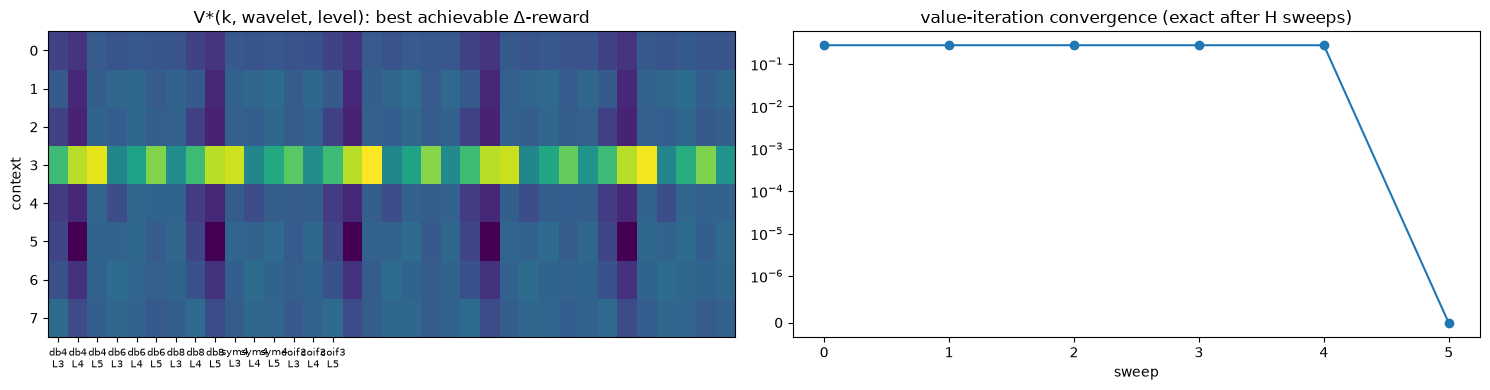

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
leaf = mdp.Rbar.reshape(K, *mdp.dims)
ax[0].imshow(leaf.max(axis=(2, 3, 4)).reshape(K, -1), aspect="auto", cmap="viridis")
ax[0].set_yticks(range(K)); ax[0].set_ylabel("context")
ax[0].set_xticks(range(15)); ax[0].set_xticklabels([f"{w}\nL{l}" for w in CFG["actions"]["wavelet"] for l in CFG["actions"]["level"]], fontsize=7)
ax[0].set_title("V*(k, wavelet, level): best achievable Δ-reward")
ax[1].plot(vi["deltas"], "o-"); ax[1].set_yscale("symlog", linthresh=1e-6); ax[1].set_xlabel("sweep"); ax[1].set_title("value-iteration convergence (exact after H sweeps)")
plt.tight_layout(); savefig(fig, "09_dp"); plt.show()
save_json({"policy": [int(c) for c in vi["policy"]], "K": K}, P["results"] / "policies" / "dp_optimum.json")